In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
# loading the csv file
df = pd.read_csv("../data/data_2024.csv", usecols=["Created Date", "Complaint Type"])

In [5]:
df["Created Date"] = pd.to_datetime(df["Created Date"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
len(df)

3361042

In [6]:
# finding the overall most abundant complaint
topComplaint = df["Complaint Type"].value_counts().idxmax()
# print(df["Complaint Type"].value_counts())
print(topComplaint)

Illegal Parking


In [10]:
illegalParking_df = df[df["Complaint Type"] == topComplaint]       

def findDailyComplaints(startDate, endDate) : 
    # adding 1 to the end date to make it inclusive
    endDate = pd.to_datetime(endDate) + pd.Timedelta(days=1)
    interval_df = illegalParking_df[(illegalParking_df["Created Date"] >= startDate) & (illegalParking_df["Created Date"] < endDate)]
    # print(len(interval_df))
    return interval_df.groupby(interval_df["Created Date"].dt.date).size()

janFeb = findDailyComplaints("2024-01-01", "2024-02-29")
junJul = findDailyComplaints("2024-06-01", "2024-07-31")
# print(janFeb)

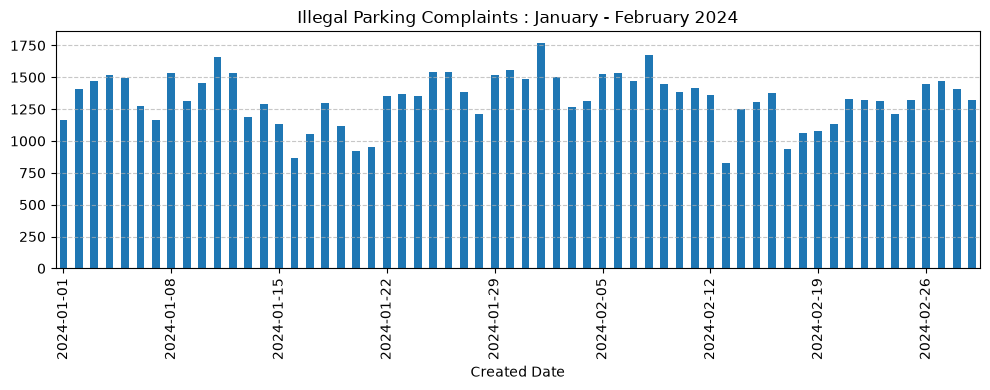

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
janFeb.plot.bar(ax=ax, title=f"{topComplaint} Complaints : January - February 2024")
ax.xaxis.set_major_locator(ticker.MultipleLocator(7))
ax.tick_params(axis="x", rotation=90)
ax.grid(axis="y", linestyle="--", alpha=0.7, zorder=0) 
plt.tight_layout()  # Adjusts layout so labels aren't cut off
plt.show()

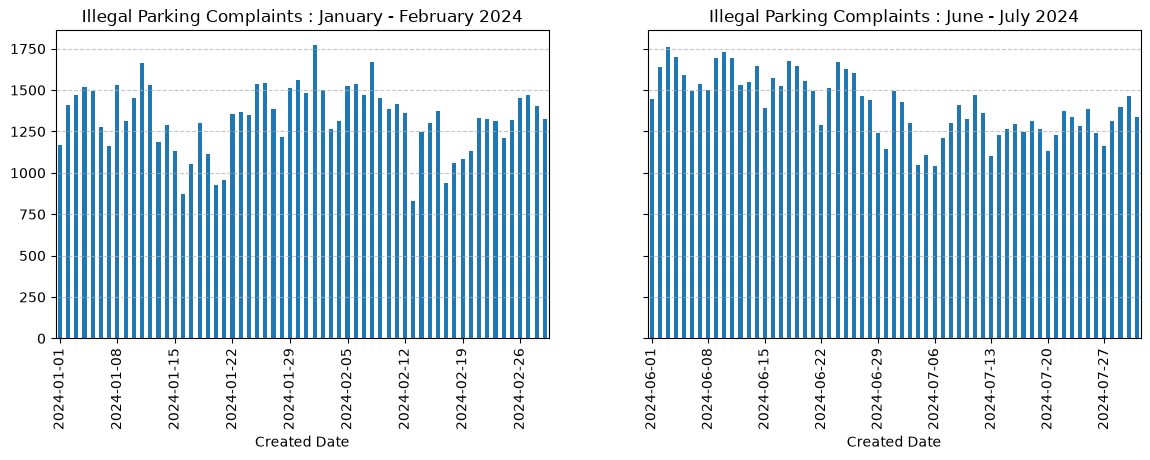

In [25]:
# plotting jan-feb and june-july
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
janFeb.plot.bar(ax=axes[0], title=f"{topComplaint} Complaints : January - February 2024")
junJul.plot.bar(ax=axes[1], title=f"{topComplaint} Complaints : June - July 2024")

for ax in axes:
    # 1 label every 7 days
    ax.xaxis.set_major_locator(ticker.MultipleLocator(7))
    ax.tick_params(axis="x", rotation=90)
    ax.grid(axis="y", linestyle="--", alpha=0.7, zorder=0)
    
plt.show()